# Feature Engineering: Encoding Substructures
Scenario: You are investigating toxicity and its dependency on molecular structure. Using the LD50 Toxicity dataset by Zhu (as provided here: https://huggingface.co/datasets/scikit-fingerprints/TDC_ld50_zhu/viewer), you calculate various molecular descriptors based on the SMILES and train a Random Forest Regressor to predict toxicity. You want to see if there is an improvement of the model when you take into account chemical structure - and generally, whether chemical structure is generally related to toxicity.

Note: the dataset is based on sparse chemical space and will not deliver super high prediction scores.

#### Tasks:
1) Load and inspect the dataset `tdc_ld50_zhu.csv`.
2) Feature engineering: Create a feature matrix `X_md` by calculating descriptors (full list as in rdkit) (Snippet provided)

3) Finding common substructures (functional groups, common scaffolds) is an alternative to detecting similarities based on fingerprints. Use the provided snippets to create different structure-based features and use one-hot encoding to make them more accessible also for other models.

4) Compare the prediction performance of the model for each of the feature matrices and combinations thereof:
- X_md: molecular descriptors only
- X_scaf: One-Hot-encoded Murcko scaffolds
- X_fg: One-hot-encoded functional groups
- X_md_scaf: Concatenation of X_md and X_scaf
- X_md_scaf_fg: Concatenation of X_md, X_scaf and X_fg

Note: For every different dataset you have to perform a train-test split and train the model before predicting. You do not need to use the suggested names!

5) Pick the best one and remove low-variance features (threshold 1%), as well as highly correlated ones (threshold 90%). See if the performance of the predictions by the model improves. Hint: Use `VarianceThreshold` (Unsupervised Algorithm from Scikit-learn) and `corr_matrix = X.corr().abs()` to do so (e.g. similarly as used in the Clustering example on the ESOL dataset)

6) Calculate Morgan Fingerprints (radius 2, 2048 bit) from the SMILES strings via mol objects. Make sure not to use the outdated version. You can use either the dataframe, numpy arrays or simple lists for the fingerprints.

7) Use Butina clustering on UMAP visualisation of the smiles-fingerprint space (scatterplot) and compare the plot side by side (e.g. as suplots) with a scatterplot colourmapped to the toxicity (look at options such as `colorbar` for matplotlib for better visualisation). 

8) Repeat 6 and 7 for the fingerprints based on the Murcko Scaffolds from task 3

9) Respond to the discussion points


Import dependencies and datasets

In [77]:
# complete imports if needed for your solution
import pandas as pd
import numpy as np

from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.Chem import AllChem
from rdkit import DataStructs
from rdkit.Chem import rdFingerprintGenerator
from rdkit.Chem import MolFromSmarts
from rdkit.Chem.Scaffolds import MurckoScaffold

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.preprocessing import OneHotEncoder

from sklearn.manifold import TSNE
import umap

import matplotlib.pyplot as plt
import seaborn as sns

from rdkit.ML.Cluster import Butina

1) Load and investigate the data

In [78]:
tox = pd.read_csv("tdc_ld50_zhu.csv")
display(tox.head())
print(tox.duplicated().sum())
print(tox.isna().sum().sum())
print(tox.describe())

,smiles,ld_50
0,[O-][N+](=Nc1ccccc1)c1ccccc1,2.505
1,BrC(Br)Br,2.343
2,C=CBr,2.330
3,Brc1ccc(-c2ccc(Br)c(Br)c2Br)c(Br)c1Br,1.465
4,S=C=Nc1ccc(Br)cc1,2.729


0
0
             ld_50
count  7376.000000
mean      2.544235
std       0.959086
min      -0.343000
25%       1.855750
50%       2.367000
75%       3.035000
max      10.207000


2) Calculate descriptors

In [79]:
descriptor_names = [d[0] for d in Descriptors._descList]

def calc_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return [desc[1](mol) for desc in Descriptors._descList]

X_md = tox.smiles.apply(calc_descriptors)

X_md = pd.DataFrame(X_md.tolist(), columns=descriptor_names)
X_md = X_md.dropna()

y = tox["ld_50"]



In [80]:
print(y)
display(X_md.head())

0       2.505
1       2.343
2       2.330
3       1.465
4       2.729
        ...  
7371    1.427
7372    2.321
7373    2.050
7374    2.951
7375    1.884
Name: ld_50, Length: 7376, dtype: float64


,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,11.564078,11.564078,0.529031,0.529031,0.412358,11.333333,198.225,188.145,198.079313,74,...,0,0,0,0,0,0,0,0,0,0
1,3.104167,3.104167,0.270833,0.270833,0.581278,9.000000,252.731,251.723,249.762836,26,...,0,0,0,0,0,0,0,0,0,0
2,3.277778,3.277778,1.562500,1.562500,0.439824,4.333333,106.950,103.926,105.941812,18,...,0,0,0,0,0,0,0,0,0,0
3,3.620234,3.620234,1.005501,1.005501,0.282041,10.777778,627.588,623.556,621.541323,94,...,0,0,0,0,0,0,0,0,0,0
4,4.438473,4.438473,0.831667,0.831667,0.516140,8.500000,214.087,210.055,212.924782,50,...,0,0,0,0,0,0,0,0,0,0


3) Find common scaffolds and encode them as binary vecotrs (one-hot-encoding). Note that the Scaffolds are represented as SMILES and can be used for fingerprints later

### Murko

In [81]:
def get_scaffold(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    scaffold = MurckoScaffold.GetScaffoldForMol(mol)
    return Chem.MolToSmiles(scaffold)

tox["scaffold"] = tox["smiles"].apply(get_scaffold).astype(str)

In [82]:
print(tox.isna().sum())
for i in tox["scaffold"]:
    if i == " ":
        print(tox.loc["i"])
display(tox.head())

smiles      0
ld_50       0
scaffold    0
dtype: int64


,smiles,ld_50,scaffold
0,[O-][N+](=Nc1ccccc1)c1ccccc1,2.505,c1ccc(N=[NH+]c2ccccc2)cc1
1,BrC(Br)Br,2.343,
2,C=CBr,2.330,
3,Brc1ccc(-c2ccc(Br)c(Br)c2Br)c(Br)c1Br,1.465,c1ccc(-c2ccccc2)cc1
4,S=C=Nc1ccc(Br)cc1,2.729,c1ccccc1


In [83]:
scaffolds = tox["scaffold"].fillna("NO_SCAFFOLD")
print(scaffolds)
len(scaffolds)
type(scaffolds)

print(scaffolds.nunique())
print(scaffolds.value_counts().head())

0                          c1ccc(N=[NH+]c2ccccc2)cc1
1                                                   
2                                                   
3                                c1ccc(-c2ccccc2)cc1
4                                           c1ccccc1
                            ...                     
7371                                        c1ccccc1
7372                                        c1ccccc1
7373                                        c1ccccc1
7374    O=C1C(=C2C=CN(CCN3CCCCC3)C=C2)C(=O)c2ccccc21
7375                                        c1ccccc1
Name: scaffold, Length: 7376, dtype: object
1677
scaffold
                    1936
c1ccccc1            1539
c1ccc2[nH]cnc2c1     131
c1ccncc1              85
C1CCCCC1              81
Name: count, dtype: int64


In [84]:
scaffold_array= scaffolds.to_numpy().reshape(-1, 1)
encoder = OneHotEncoder( handle_unknown="ignore", sparse_output=False) # better to provide catas, otherwise it will learn it from the data

X_scaf = encoder.fit_transform(scaffold_array)
X_scaf = pd.DataFrame(
    X_scaf,
    columns=encoder.get_feature_names_out(["scaffold"])
)
print(X_scaf)

      scaffold_  scaffold_C(#Cc1ccccc1)Cc1ccccc1  \
0           0.0                              0.0   
1           1.0                              0.0   
2           1.0                              0.0   
3           0.0                              0.0   
4           0.0                              0.0   
...         ...                              ...   
7371        0.0                              0.0   
7372        0.0                              0.0   
7373        0.0                              0.0   
7374        0.0                              0.0   
7375        0.0                              0.0   

      scaffold_C(=C(c1ccccc1)c1ccccc1)c1ccccc1  \
0                                          0.0   
1                                          0.0   
2                                          0.0   
3                                          0.0   
4                                          0.0   
...                                        ...   
7371                     

In [85]:
print(len(encoder.get_feature_names_out(["scaffold"])))
print(encoder.get_feature_names_out(["scaffold"])[:10])

1677
['scaffold_' 'scaffold_C(#Cc1ccccc1)Cc1ccccc1'
 'scaffold_C(=C(c1ccccc1)c1ccccc1)c1ccccc1'
 'scaffold_C(=C1SCC(c2ccccc2)S1)n1ccnc1'
 'scaffold_C(=CSSCC1CCCO1)NCc1cncnc1'
 'scaffold_C(=Cc1ccccc1)C(C=Cc1ccccc1)=NN=C1NCCCN1'
 'scaffold_C(=Cc1ccccc1)CN1CCN(c2cccnn2)CC1'
 'scaffold_C(=Cc1ccccc1)c1ccccc1' 'scaffold_C(=Cc1ccco1)c1ccccn1'
 'scaffold_C(=Cc1ccco1)c1ccco1']


Instead of structural scaffolds (via SMARTS), encode functional groups using the one-hot-encoder. Add some more functional groups that you think have impact on the toxicity of compounds.

In [105]:
functional_groups = {
    "amine": "[NX3;H2,H1;!$(NC=O)]",
    "carboxylic_acid": "C(=O)[OX2H1]",
    "aromatic_ring": "a",
    "halogen": "[F,Cl,Br,I]",
    "nitro": "[N+](=O)[O-]"#,
    #"alcohol": "OH"
    
}

In [106]:
patterns = {k: Chem.MolFromSmarts(v) for k,v in functional_groups.items()}

def detect_groups(smiles):
    mol = Chem.MolFromSmiles(smiles)
    return {
        name: int(mol.HasSubstructMatch(pat))
        for name, pat in patterns.items()
    }

X_fg = pd.DataFrame(
    tox["smiles"].apply(detect_groups).tolist()
)

In [96]:
display(X_md.head(), X_md.shape)
display(X_scaf.head(), X_scaf.shape)
display(X_fg.head(), X_fg.shape)

,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,11.564078,11.564078,0.529031,0.529031,0.412358,11.333333,198.225,188.145,198.079313,74,...,0,0,0,0,0,0,0,0,0,0
1,3.104167,3.104167,0.270833,0.270833,0.581278,9.000000,252.731,251.723,249.762836,26,...,0,0,0,0,0,0,0,0,0,0
2,3.277778,3.277778,1.562500,1.562500,0.439824,4.333333,106.950,103.926,105.941812,18,...,0,0,0,0,0,0,0,0,0,0
3,3.620234,3.620234,1.005501,1.005501,0.282041,10.777778,627.588,623.556,621.541323,94,...,0,0,0,0,0,0,0,0,0,0
4,4.438473,4.438473,0.831667,0.831667,0.516140,8.500000,214.087,210.055,212.924782,50,...,0,0,0,0,0,0,0,0,0,0


(7376, 217)

,scaffold_,scaffold_C(#Cc1ccccc1)Cc1ccccc1,scaffold_C(=C(c1ccccc1)c1ccccc1)c1ccccc1,scaffold_C(=C1SCC(c2ccccc2)S1)n1ccnc1,scaffold_C(=CSSCC1CCCO1)NCc1cncnc1,scaffold_C(=Cc1ccccc1)C(C=Cc1ccccc1)=NN=C1NCCCN1,scaffold_C(=Cc1ccccc1)CN1CCN(c2cccnn2)CC1,scaffold_C(=Cc1ccccc1)c1ccccc1,scaffold_C(=Cc1ccco1)c1ccccn1,scaffold_C(=Cc1ccco1)c1ccco1,...,scaffold_c1ncn(C2CCCO2)n1,scaffold_c1ncnc(N(CCCCCCN(c2ncncn2)C2CCNCC2)C2CCNCC2)n1,scaffold_c1ncnc(NC2CC2)n1,scaffold_c1ncncn1,scaffold_c1ncsn1,scaffold_c1nnc(NCNc2nncs2)s1,scaffold_c1nnc[nH]1,scaffold_c1nnco1,scaffold_c1nncs1,scaffold_n1o[nH+]c2c1c1[nH+]onc1c1[nH+]onc21
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


(7376, 1677)

,amine,carboxylic_acid,aromatic_ring,halogen,nitro
0,0,0,1,0,0
1,0,0,0,1,0
2,0,0,0,1,0
3,0,0,1,1,0
4,0,0,1,1,0


(7376, 5)

In [108]:
X_md_scaf= pd.concat([X_md, X_scaf], axis=1)
X_md_scaf_fg = pd.concat([X_md_scaf, X_fg], axis=1)


In [110]:
display(X_md_scaf.head(), X_md_scaf.shape)

display(X_md_scaf_fg.head(), X_md_scaf_fg.shape)

,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,scaffold_c1ncn(C2CCCO2)n1,scaffold_c1ncnc(N(CCCCCCN(c2ncncn2)C2CCNCC2)C2CCNCC2)n1,scaffold_c1ncnc(NC2CC2)n1,scaffold_c1ncncn1,scaffold_c1ncsn1,scaffold_c1nnc(NCNc2nncs2)s1,scaffold_c1nnc[nH]1,scaffold_c1nnco1,scaffold_c1nncs1,scaffold_n1o[nH+]c2c1c1[nH+]onc1c1[nH+]onc21
0,11.564078,11.564078,0.529031,0.529031,0.412358,11.333333,198.225,188.145,198.079313,74,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,3.104167,3.104167,0.270833,0.270833,0.581278,9.000000,252.731,251.723,249.762836,26,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3.277778,3.277778,1.562500,1.562500,0.439824,4.333333,106.950,103.926,105.941812,18,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,3.620234,3.620234,1.005501,1.005501,0.282041,10.777778,627.588,623.556,621.541323,94,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,4.438473,4.438473,0.831667,0.831667,0.516140,8.500000,214.087,210.055,212.924782,50,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


(7376, 1894)

,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,scaffold_c1nnc(NCNc2nncs2)s1,scaffold_c1nnc[nH]1,scaffold_c1nnco1,scaffold_c1nncs1,scaffold_n1o[nH+]c2c1c1[nH+]onc1c1[nH+]onc21,amine,carboxylic_acid,aromatic_ring,halogen,nitro
0,11.564078,11.564078,0.529031,0.529031,0.412358,11.333333,198.225,188.145,198.079313,74,...,0.0,0.0,0.0,0.0,0.0,0,0,1,0,0
1,3.104167,3.104167,0.270833,0.270833,0.581278,9.000000,252.731,251.723,249.762836,26,...,0.0,0.0,0.0,0.0,0.0,0,0,0,1,0
2,3.277778,3.277778,1.562500,1.562500,0.439824,4.333333,106.950,103.926,105.941812,18,...,0.0,0.0,0.0,0.0,0.0,0,0,0,1,0
3,3.620234,3.620234,1.005501,1.005501,0.282041,10.777778,627.588,623.556,621.541323,94,...,0.0,0.0,0.0,0.0,0.0,0,0,1,1,0
4,4.438473,4.438473,0.831667,0.831667,0.516140,8.500000,214.087,210.055,212.924782,50,...,0.0,0.0,0.0,0.0,0.0,0,0,1,1,0


(7376, 1899)

### Train Test 

In [111]:
from sklearn.metrics import mean_squared_error

In [132]:
def perform_regression(X, y):

    #test train
    X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42)



    #regression
    rfr=RandomForestRegressor(random_state=42)
    rfr.fit(X_train, y_train)

    rfr_y_test_pred = rfr.predict(X_test)
    rfr_y_train_pred = rfr.predict(X_train)

    #RMSE=[]
    #r2=[]
    #train_r2=[]
    #train_rmse=[]

    rfr_r2 = r2_score(y_test, rfr_y_test_pred)
    rfr_rmse =(mean_squared_error(y_test, rfr_y_test_pred))**.5

    #r2.append(rfr_r2)
    #RMSE.append(rfr_rmse)

    ### training

    rfr_train_r2 = r2_score(y_train, rfr_y_train_pred)
    rfr_train_rmse = (mean_squared_error(y_train, rfr_y_train_pred))**.5


    #train_r2.append(rfr_train_r2)
    #train_rmse.append(rfr_train_rmse)

    return rfr, rfr_y_test_pred, rfr_y_train_pred, {"Name": "f{X}","RMSE": rfr_rmse, "r2": rfr_r2, "train_r2": rfr_train_r2, "train_rmse": rfr_train_rmse}

In [133]:
X_md_model, X_md_test_pred, X_md_train_pred, X_md_dic =  perform_regression(X_md, y)

In [ ]:
X_scaf_model, X_scaf_test_pred, X_scaf_train_pred, X_scaf_dic =  perform_regression(X_scaf, y)

In [ ]:
X_fg_test_model, X_fg_test_pred, X_fg_train_pred, X_fg_dic =  perform_regression(X_fg, y)

In [ ]:
X_md_scaf_model, X_md_scaf_test_pred, X_md_scaf_train_pred, X_md_scaf_dic =  perform_regression(X_md_scaf, y)

In [ ]:
X_md_scaf_fg_model, X_md_scaf_fg_test_pred, X_md_scaf_fg_train_pred, X_md_scaf_fg_dic =  perform_regression(X_md_scaf_fg, y)

In [130]:
print(X_md_dic, "\n", X_scaf_dic, "\n", X_fg_dic, "\n", X_md_scaf_dic, "\n", X_md_scaf_fg_dic)

{'Name': 'f{X}', 'RMSE': 0.6061552775508172, 'r2': 0.6186977959186364, 'train_r2': 0.9441873636855357, 'train_rmse': 0.22519461218604273} 
 {'Name': 'f{X}', 'RMSE': 0.8739382045248215, 'r2': 0.2073837271426462, 'train_r2': 0.387252064496341, 'train_rmse': 0.7461611886889413} 
 {'Name': 'f{X}', 'RMSE': 0.9542875615923075, 'r2': 0.054938523216820245, 'train_r2': 0.058189014781429016, 'train_rmse': 0.9250678829670109} 
 {'Name': 'f{X}', 'RMSE': 0.6097944109710745, 'r2': 0.6141056559355522, 'train_r2': 0.9450246735865491, 'train_rmse': 0.22349902639346556} 
 {'Name': 'f{X}', 'RMSE': 0.6094125104969403, 'r2': 0.6145888584118254, 'train_r2': 0.9453139315959818, 'train_rmse': 0.22291027002530014}


> choosing X_md, mol descriptors only, lowest RMSE, highest r2, lowkey kind of bad tho

5) Pick the best one and prune the features regarding variance and correlation. Run the regression model again and compare the performance.

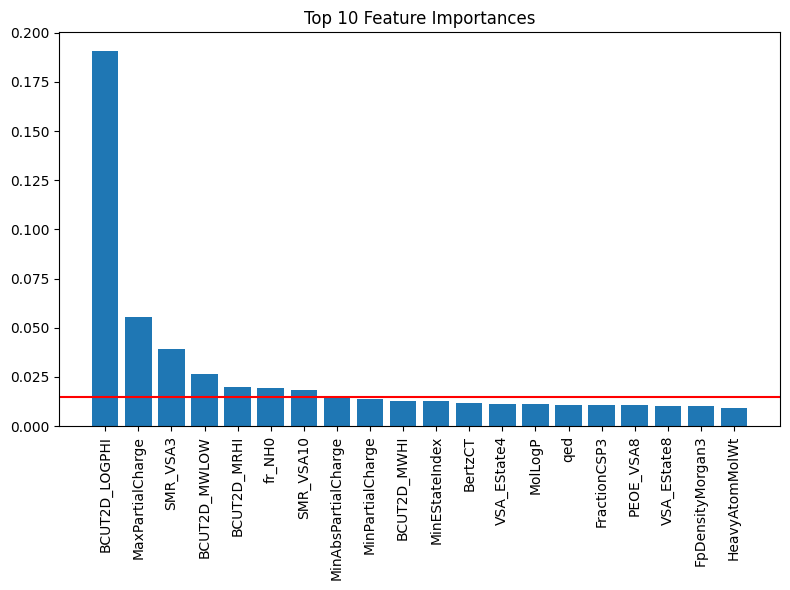

BCUT2D_LOGPHI: 0.191
MaxPartialCharge: 0.056
SMR_VSA3: 0.039
BCUT2D_MWLOW: 0.027
BCUT2D_MRHI: 0.020
fr_NH0: 0.019
SMR_VSA10: 0.018
MinAbsPartialCharge: 0.015
MinPartialCharge: 0.014
BCUT2D_MWHI: 0.013
MinEStateIndex: 0.013
BertzCT: 0.012
VSA_EState4: 0.011
MolLogP: 0.011
qed: 0.011
FractionCSP3: 0.011
PEOE_VSA8: 0.011
VSA_EState8: 0.010
FpDensityMorgan3: 0.010
HeavyAtomMolWt: 0.009


In [145]:
importances = X_md_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(8, 6))
plt.bar(range(20), importances[indices][:20])
plt.xticks(range(20), X_md.columns[indices][:20], rotation=90)


plt.axhline(y=0.015, color='r', linestyle='-')


plt.title("Top 10 Feature Importances")
plt.tight_layout()
plt.show()

for name, imp in sorted(zip(X_md.columns[indices][:20], importances[indices][:20]), key=lambda x: -x[1]):
    print(f"{name}: {imp:.3f}")

> only keeping the best 7 features

In [143]:
print(X_md.columns[indices][:7])

Index(['BCUT2D_LOGPHI', 'MaxPartialCharge', 'SMR_VSA3', 'BCUT2D_MWLOW',
       'BCUT2D_MRHI', 'fr_NH0', 'SMR_VSA10'],
      dtype='object')


In [151]:
feature_df = X_md[['BCUT2D_LOGPHI', 'MaxPartialCharge', 'SMR_VSA3', 'BCUT2D_MWLOW',
       'BCUT2D_MRHI', 'fr_NH0', 'SMR_VSA10']]

In [152]:
feature_model, feature_test_pred, feature_train_pred, feature_dic =  perform_regression(feature_df, y)

In [154]:
print(X_md_dic, "\n",feature_dic)

{'Name': 'f{X}', 'RMSE': 0.6061552775508172, 'r2': 0.6186977959186364, 'train_r2': 0.9441873636855357, 'train_rmse': 0.22519461218604273} 
 {'Name': 'f{X}', 'RMSE': 0.6653162698906602, 'r2': 0.5406350847806458, 'train_r2': 0.9347150632087206, 'train_rmse': 0.24355565699804244}


6) Generate Morgan fingerprints (2048 bit, radius=2) for both "smiles" (entire molecules) and "scaffolds" (SMILES of common scaffolds only)

In [169]:
display(tox.head())
display((tox["scaffold"]=="").sum())
display(scaffolds[1])


scaffold_clean= tox["scaffold"].copy().replace("", np.nan, inplace=True)
scaffold_clean= tox.dropna(subset=["scaffold"], inplace=True)
display(scaffold_clean)

,smiles,ld_50,scaffold
0,[O-][N+](=Nc1ccccc1)c1ccccc1,2.505,c1ccc(N=[NH+]c2ccccc2)cc1
3,Brc1ccc(-c2ccc(Br)c(Br)c2Br)c(Br)c1Br,1.465,c1ccc(-c2ccccc2)cc1
4,S=C=Nc1ccc(Br)cc1,2.729,c1ccccc1
5,O=c1[nH]c2ccc(Br)cc2o1,2.330,O=c1[nH]c2ccccc2o1
6,Brc1ccccc1,1.765,c1ccccc1


np.int64(0)

''

None

In [171]:
tox["scaffold"].copy().replace("", np.nan, inplace=True)
display(tox)

,smiles,ld_50,scaffold
0,[O-][N+](=Nc1ccccc1)c1ccccc1,2.505,c1ccc(N=[NH+]c2ccccc2)cc1
3,Brc1ccc(-c2ccc(Br)c(Br)c2Br)c(Br)c1Br,1.465,c1ccc(-c2ccccc2)cc1
4,S=C=Nc1ccc(Br)cc1,2.729,c1ccccc1
5,O=c1[nH]c2ccc(Br)cc2o1,2.330,O=c1[nH]c2ccccc2o1
6,Brc1ccccc1,1.765,c1ccccc1
...,...,...,...
7371,O=C=Nc1ccccc1C(F)(F)F,1.427,c1ccccc1
7372,Nc1ccc(OC(F)(F)C(F)F)c(N)c1,2.321,c1ccccc1
7373,CC(=O)OCCN(CCC#N)c1ccccc1,2.050,c1ccccc1
7374,CC1=CC(=C2C(=O)c3ccccc3C2=O)C=CN1CCN1CCCCC1,2.951,O=C1C(=C2C=CN(CCN3CCCCC3)C=C2)C(=O)c2ccccc21


In [172]:
mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

def smiles_to_fp(smiles, scaffolds):
    # string!!!!!!
    if not isinstance(smiles, str):
        return None
    mol = Chem.MolFromSmiles(smiles)
    scaf = Chem.MolFromSmiles(scaffolds)

    if mol is None:
        return None
    if scaf is None:
        return None
    fp_mol = mfpgen.GetFingerprint(mol)
    fp_scaf = mfpgen.GetFingerprint(scaf)
    return fp_mol, fp_scaf

In [173]:
# Convert to fingerprints
smile_fps = []
scaf_fps = []
for smiles, scaf in zip(tox["smiles"], tox["scaffold"]):

    fp_0, fp_1 = smiles_to_fp(smiles, scaf)

    if fp_0 or fp_1 is not None:
        smile_fps.append(fp_0)
        scaf_fps.append(fp_1)


In [179]:
print(len(smile_fps), len(scaf_fps))

5440 5440


7) Butina clustering (as in last exercise): Experiment with different cutoffs and filter limits for the clusters (compare in the visualisation, no need to rerun the UMAP visualisation in between)

In [175]:
smile_dists = []
smile_nfps = len(smile_fps)
cutoff = 0.6

for i in range(1, smile_nfps):
    smile_sims = DataStructs.BulkTanimotoSimilarity(smile_fps[i], smile_fps[:i])
    smile_dists.extend([1-x for x in smile_sims])

smile_clusters = Butina.ClusterData(
    smile_dists,
    smile_nfps,
    cutoff,
    isDistData=True
)

print("Number of clusters:", len(smile_clusters))

Number of clusters: 1857


In [181]:
scaf_dists = []
scaf_nfps = len(scaf_fps)
cutoff = 0.6

for i in range(1, scaf_nfps):
    scaf_sims = DataStructs.BulkTanimotoSimilarity(scaf_fps[i], scaf_fps[:i])
    scaf_dists.extend([1-x for x in scaf_sims])

scaf_clusters = Butina.ClusterData(
    scaf_dists,
    scaf_nfps,
    cutoff,
    isDistData=True
)

print("Number of clusters:", len(scaf_clusters))

Number of clusters: 746


In [182]:
# filter out small clusters, rare chemoptypes, ...
smile_clusters_filtered = [c for c in smile_clusters if len(c) >= 5]

smile_butina_labels = np.full(smile_nfps, -1)
for cluster_id, cluster in enumerate(smile_clusters_filtered):
    for id in cluster:
        smile_butina_labels[id] = cluster_id

smile_sizes = [len(c) for c in smile_clusters_filtered]

print("clusters:", len(smile_sizes))
print("mean size:", np.mean(smile_sizes))
print("max size:", np.max(smile_sizes))
print("singletons:", sum(s == 1 for s in smile_sizes))




clusters: 245
mean size: 12.49795918367347
max size: 92
singletons: 0


In [183]:

# filter out small clusters, rare chemoptypes, ...
scaf_clusters_filtered = [c for c in scaf_clusters if len(c) >= 5]

scaf_butina_labels = np.full(scaf_nfps, -1)
for cluster_id, cluster in enumerate(scaf_clusters_filtered):
    for id in cluster:
        scaf_butina_labels[id] = cluster_id

scaf_sizes = [len(c) for c in scaf_clusters_filtered]

print("clusters:", len(scaf_sizes))
print("mean size:", np.mean(scaf_sizes))
print("max size:", np.max(scaf_sizes))
print("singletons:", sum(s == 1 for s in scaf_sizes))

clusters: 160
mean size: 28.425
max size: 1539
singletons: 0


Calculate UMAP space - play with `n_neighbors` and `min_distance` until you are satisfied with the visualisation.

In [184]:
# convert fingerprints to numpy
smile_fp_array = np.zeros((smile_nfps, 2048), dtype=int)
for i, fp in enumerate(smile_fps):
    DataStructs.ConvertToNumpyArray(fp, smile_fp_array[i])

In [185]:
# convert fingerprints to numpy
scaf_fp_array = np.zeros((scaf_nfps, 2048), dtype=int)
for i, fp in enumerate(scaf_fps):
    DataStructs.ConvertToNumpyArray(fp, scaf_fp_array[i])

In [187]:
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)

smile_umap_emb = reducer.fit_transform(smile_fp_array)
scaf_umap_emb = reducer.fit_transform(scaf_fp_array)

/Users/verityjanerothermelsmith/Library/Mobile Documents/com~apple~CloudDocs/Uni/FS2026/git/DSA104/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Visualise the UMAP space with the a) the cluster labels and b) the toxicity as colour hue. (Incomplete snippet for matplotlib provided - feel free to use whatever visualisation that works best for you)

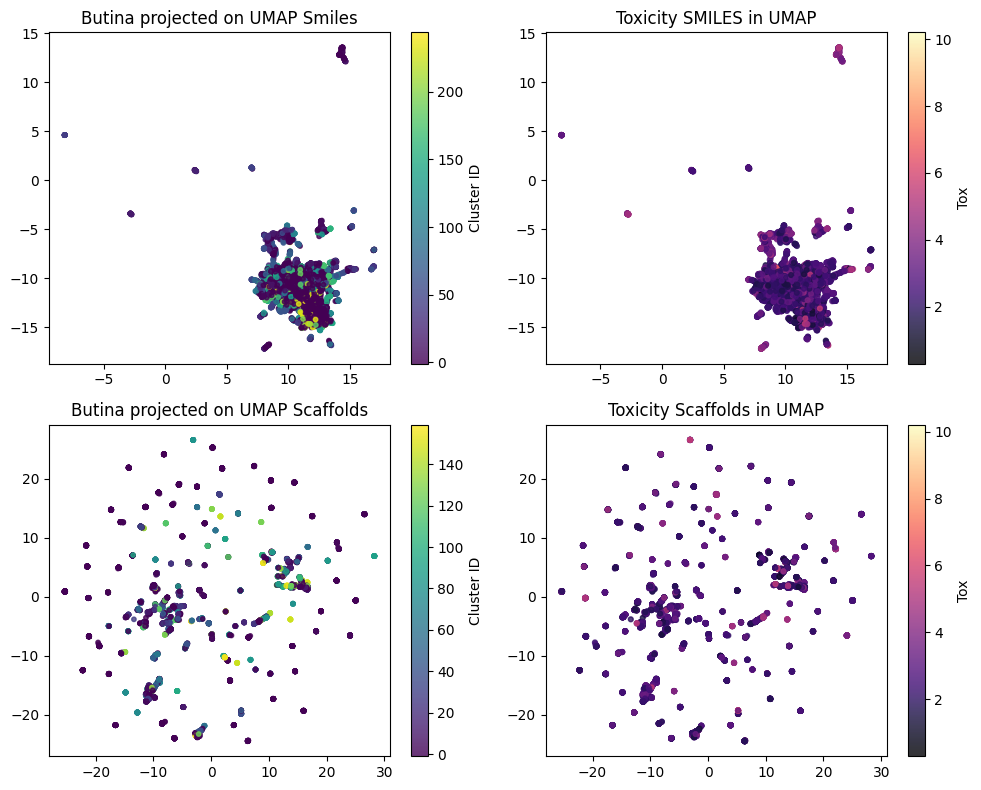

In [199]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 8))

sc0=axes[0, 0].scatter(smile_umap_emb[:, 0], smile_umap_emb[:, 1], c=smile_butina_labels, cmap="viridis",
    s=10,
    alpha=0.8)
axes[0, 0].set_title("Butina projected on UMAP Smiles")

smile_tox_umap = tox['ld_50'].to_numpy()[:len(smile_umap_emb)]
sc1 = axes[0,1].scatter(
    smile_umap_emb[:, 0],
    smile_umap_emb[:, 1],
    c=smile_tox_umap,
    cmap='magma',
    s=12,
    alpha=0.8
)
axes[0,1].set_title("Toxicity SMILES in UMAP")




sc2=axes[1, 0].scatter(scaf_umap_emb[:, 0], scaf_umap_emb[:, 1], c=scaf_butina_labels, cmap="viridis",
    s=10,
    alpha=0.8)
axes[1,0].set_title("Butina projected on UMAP Scaffolds")

scaf_tox_umap = tox['ld_50'].to_numpy()[:len(scaf_umap_emb)]
sc3 = axes[1,1].scatter(
    scaf_umap_emb[:, 0],
    scaf_umap_emb[:, 1],
    c=scaf_tox_umap,
    cmap='magma',
    s=12,
    alpha=0.8

)
axes[1,1].set_title("Toxicity Scaffolds in UMAP")

fig.colorbar(sc0, ax=axes[0,0], label="Cluster ID")
fig.colorbar(sc1, ax=axes[0,1], label="Tox")


fig.colorbar(sc2, ax=axes[1,0], label="Cluster ID")
fig.colorbar(sc3, ax=axes[1,1], label="Tox")


"""sc0.set(xlabel ="UMAP 1", ylabel="UMAP 2")
sc0.set_title("Butina clusters")

sc1.set(xlabel ="UMAP 1", ylabel="UMAP 2")
sc1.set_title("Butina clusters")"""

# Adjusting layout
plt.tight_layout()

# Show the plots
plt.show()


#### 9) Discussion points
1) How did the scaffolds and functional groups perform in the model performance in comparison the molecular descriptors? Comment on possible reasons. Which combination was suited best?
2) Is the One-Hot Encoding needed in this case?
3) Did the feature filtering (variance, correlation) have an improving effect? Explain!
4) Consider to make this kind of workflow for feature comparison more generally usable: How would a clean solution look? How could you ensure compatibility with other models? How would the function / pipeline look schematically?
5) Visualisation: Using the scaffold fingerprints and the fingerprints for the entire molecule makes a huge difference. What is reason for this effect? Discuss this approach in contrast to similarity thresholds in the Butina clustering.
6) When might scaffolding prove useful?
7) Is toxicity correlated to molecular structure? I.e. what did the toxicity map in UMAP space reveal?


1) both had higher RSME (0.8739382045248215, 0.9542875615923075) and lower r2 values 80.2073837271426462, 0.054938523216820245. Best with best metrics was jus tht smiles. 

2) yes, to avoid giving the model biased info on how important ccertain labels are

3) no, but I thinkI did something wrong regarding the correlation aspect ( should have used VarianceThreshold, only saw that I did it wrong when cpm. with the Aufgabendescription before submitting :(

4) ? input, clean , feature generator, model (?)

5) could help identify whether certain core structures are associated with higher or lower activity or toxicity trends

6) Yes, I feel like we can see it a little bit on the scaffolds maps. Smiles one lump so a little bit difficult to see.